# Clustering 

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pickle
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from functions import *
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
with open('processed_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_scaled = loaded_data['X_scaled']
habit_features = loaded_data['feature_names']
df = loaded_data['original_df']

print(f"Ready to cluster {X_scaled.shape[0]} rows with {len(habit_features)} features.")

Ready to cluster 2000 rows with 10 features.


## K-means

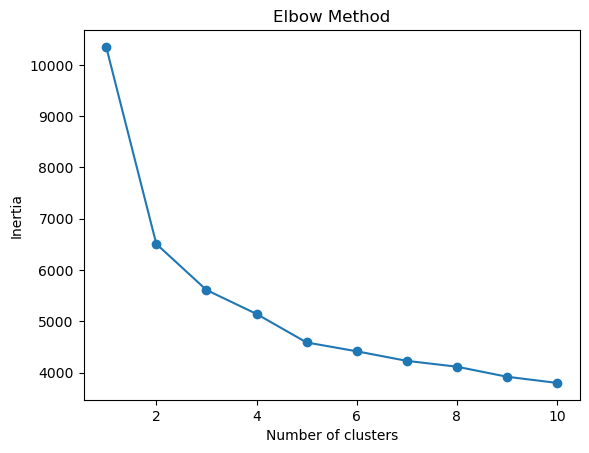

In [73]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [74]:
print("Inertia values:", [round(x, 2) for x in inertia])

Inertia values: [10348.85, 6508.22, 5610.58, 5143.03, 4586.5, 4414.58, 4228.08, 4114.19, 3918.32, 3797.8]


By the elbow curve, the suggested number of clusters could be 3 (or 4).

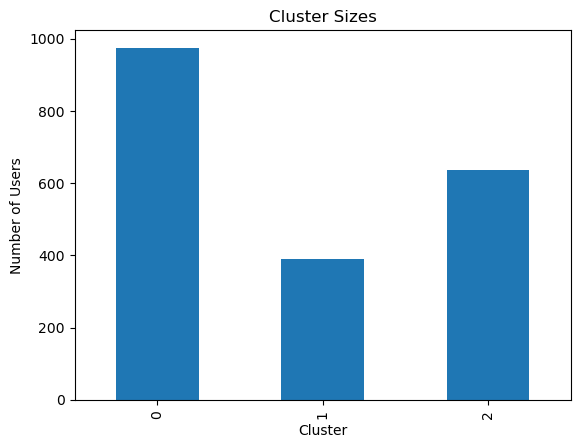

In [75]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_3.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['cluster_kmeans'] = clusters

df.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

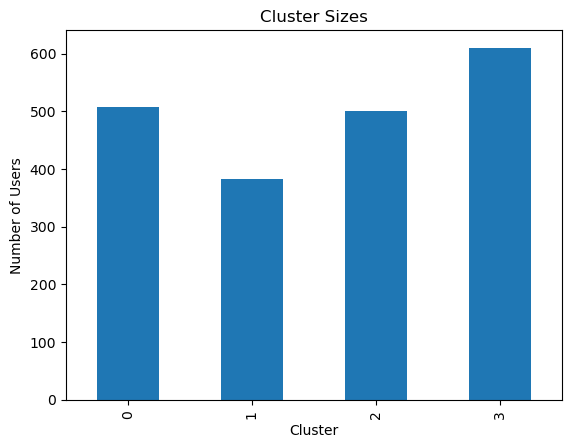

In [76]:
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans_4.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['cluster_kmeans'] = clusters

df.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

Cluster centroids (mean values for each feature):
                work_hours  meetings_count  breaks_taken  after_hours_work  \
cluster_kmeans                                                               
0                 8.724823        3.582677      3.980315          0.104331   
1                11.563639        7.447644      3.680628          0.369110   
2                 8.591060        1.510000      5.288000          0.138000   
3                 7.814656        3.339344      6.655738          0.081967   

                app_switches  sleep_hours  task_completion  isolation_index  \
cluster_kmeans                                                                
0                  48.667323     7.463996        79.286969         3.887795   
1                  85.761780     5.554110        67.120105         6.413613   
2                  53.376000     6.650600        81.745140         5.904000   
3                  45.703279     7.460852        87.526410         3.891803   

      

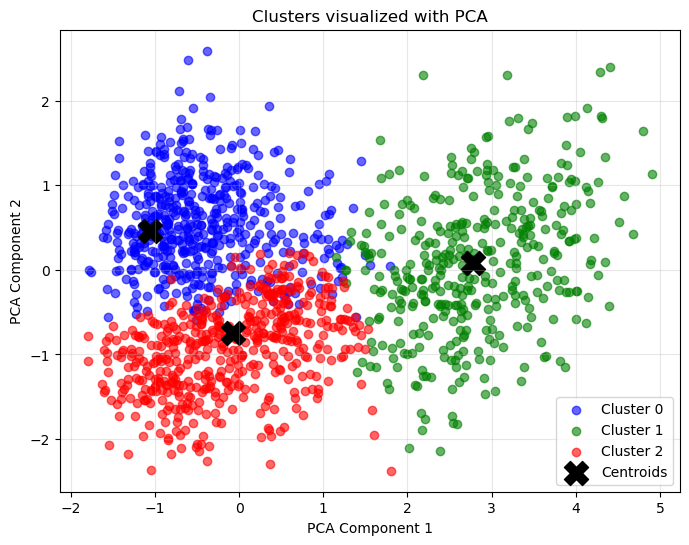

In [77]:
cluster_summary = df.groupby('cluster_kmeans')[habit_features].mean()
print("Cluster centroids (mean values for each feature):")
print(cluster_summary)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids to PCA space
centroids_pca = pca.transform(kmeans_3.cluster_centers_)

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for cluster in range(3):
    plt.scatter(X_pca[clusters == cluster, 0], X_pca[clusters == cluster, 1], 
                label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

K-means Silhouette Score: 0.174


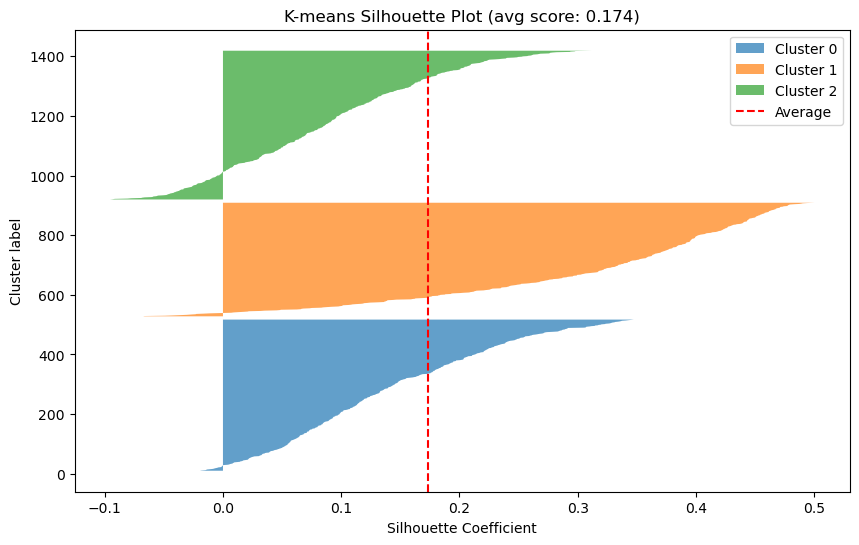

In [78]:
from sklearn.metrics import silhouette_score, silhouette_samples

# Calculate silhouette score for K-means
silhouette_avg_kmeans = silhouette_score(X_scaled, clusters)
print(f"K-means Silhouette Score: {silhouette_avg_kmeans:.3f}")

# Silhouette analysis plot
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(3):
    cluster_silhouette_vals = silhouette_samples(X_scaled, clusters)[clusters == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster label')
ax.set_title(f'K-means Silhouette Plot (avg score: {silhouette_avg_kmeans:.3f})')
ax.axvline(x=silhouette_avg_kmeans, color='red', linestyle='--', label='Average')
ax.legend()
plt.show()

PCA 2 components - Explained variance: 0.6274
PCA 3 components - Explained variance: 0.7498
Individual components (3-component PCA):
  PC1: 0.4891
  PC2: 0.1383
  PC3: 0.1224


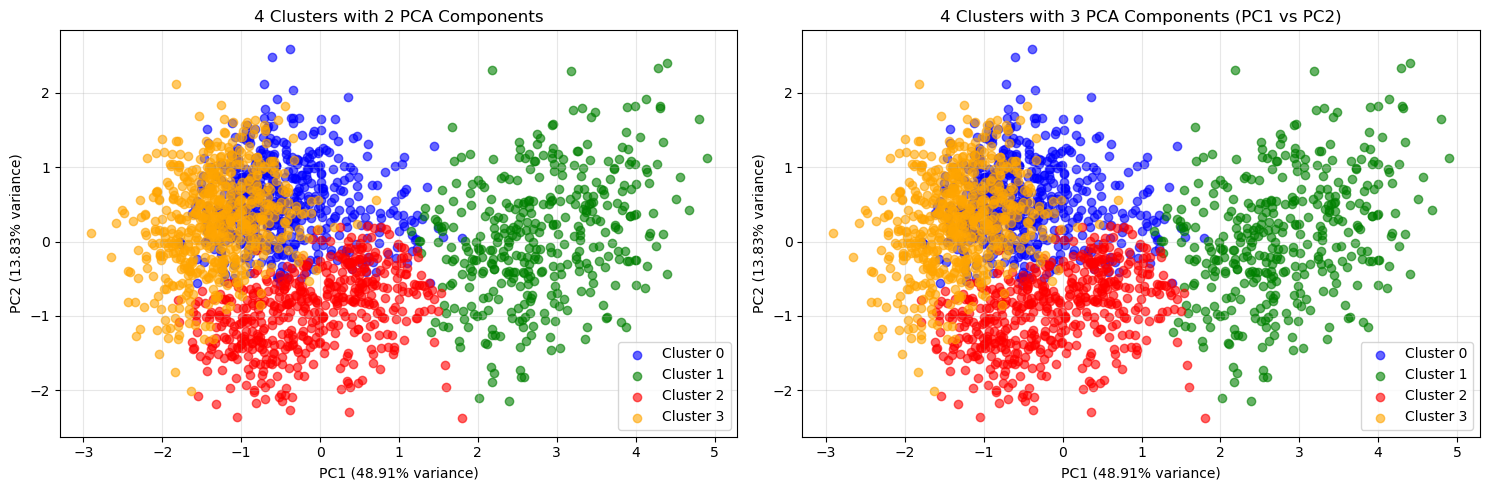


Observation: Compare the cluster separation in both visualizations above.


In [79]:
# Compare PCA with 2 vs 3 components for 4-cluster model

# PCA with 2 components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# PCA with 3 components  
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print(f"PCA 2 components - Explained variance: {pca_2.explained_variance_ratio_.sum():.4f}")
print(f"PCA 3 components - Explained variance: {pca_3.explained_variance_ratio_.sum():.4f}")
print(f"Individual components (3-component PCA):")
for i, var in enumerate(pca_3.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}")

# Get cluster assignments for 4-cluster model
clusters_4 = kmeans_4.fit_predict(X_scaled)

# Visualize 4 clusters with 2 PCA components
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['blue', 'green', 'red', 'orange']
for cluster in range(4):
    axes[0].scatter(X_pca_2[clusters_4 == cluster, 0], X_pca_2[clusters_4 == cluster, 1], 
                    label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
axes[0].set_title('4 Clusters with 2 PCA Components')
axes[0].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visualize 4 clusters with 3 PCA components (2D projection)
for cluster in range(4):
    axes[1].scatter(X_pca_3[clusters_4 == cluster, 0], X_pca_3[clusters_4 == cluster, 1], 
                    label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
axes[1].set_title('4 Clusters with 3 PCA Components (PC1 vs PC2)')
axes[1].set_xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]:.2%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]:.2%} variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation: Compare the cluster separation in both visualizations above.")

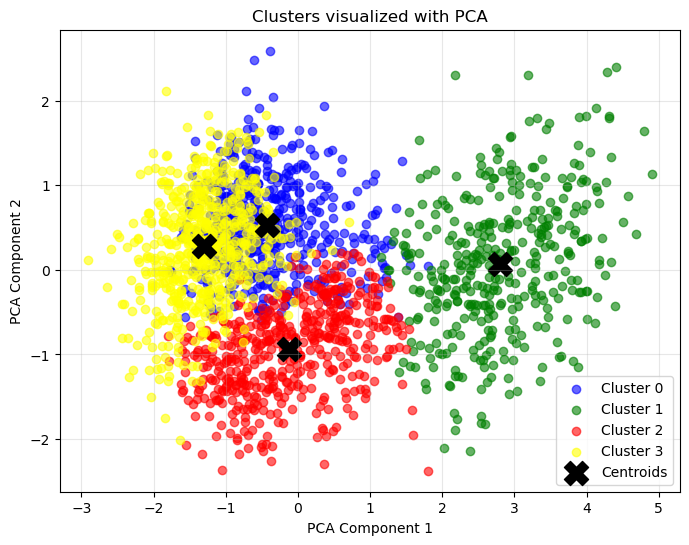

In [80]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids to PCA space
centroids_pca = pca.transform(kmeans_4.cluster_centers_)

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red', 'yellow']
for cluster in range(4):
    plt.scatter(X_pca[clusters == cluster, 0], X_pca[clusters == cluster, 1], 
                label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

K-means Silhouette Score: 0.174


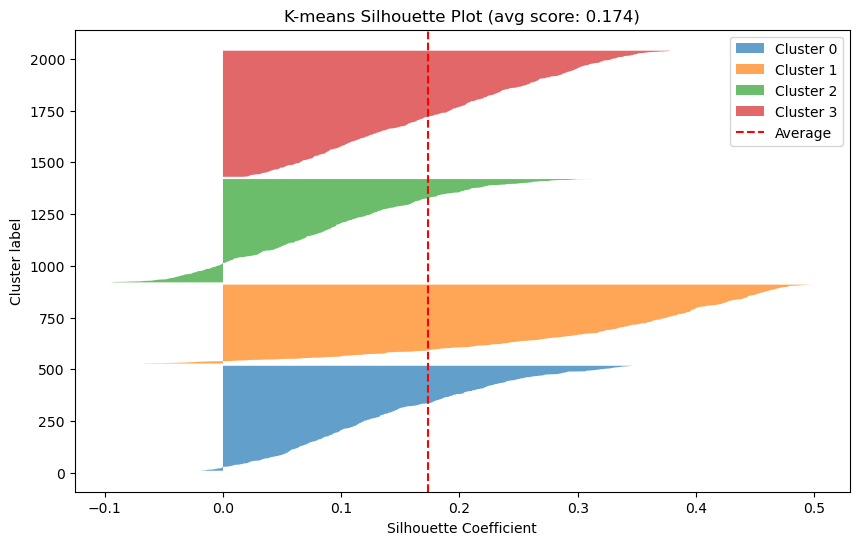

In [81]:


# Calculate silhouette score for K-means
silhouette_avg_kmeans = silhouette_score(X_scaled, clusters)
print(f"K-means Silhouette Score: {silhouette_avg_kmeans:.3f}")

# Silhouette analysis plot
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(4):
    cluster_silhouette_vals = silhouette_samples(X_scaled, clusters)[clusters == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster label')
ax.set_title(f'K-means Silhouette Plot (avg score: {silhouette_avg_kmeans:.3f})')
ax.axvline(x=silhouette_avg_kmeans, color='red', linestyle='--', label='Average')
ax.legend()
plt.show()

## Hierarchical clustering

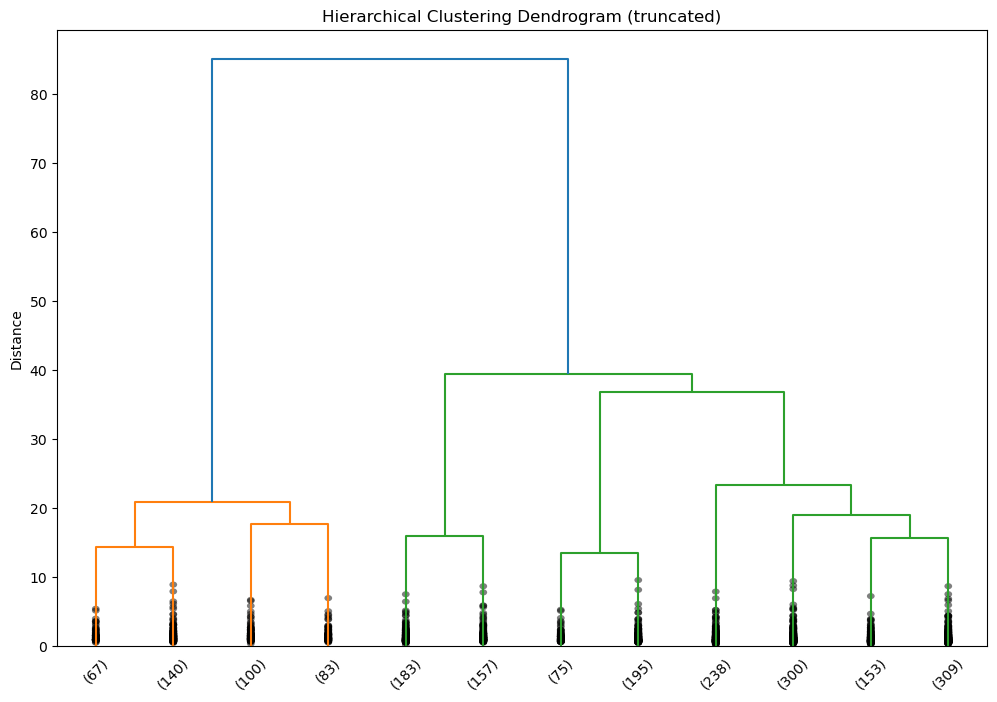

In [82]:

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=45., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.ylabel('Distance') 
plt.show()

The dendogram suggests 3 clusters.

K-means cluster sizes:
cluster_kmeans
0    508
1    382
2    500
3    610
dtype: int64

Hierarchical cluster sizes:
cluster_hier
0     390
1     340
2    1270
dtype: int64

Adjusted Rand Index between K-means and Hierarchical: 0.298


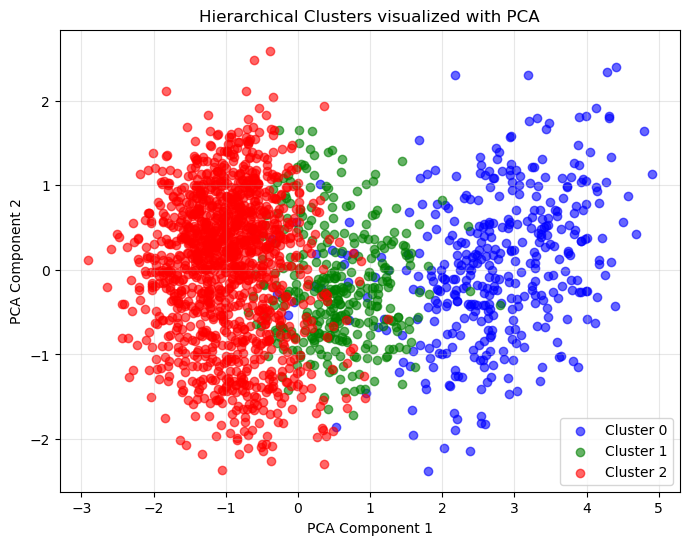

In [83]:
clusters_hier = fcluster(Z, 3, criterion='maxclust')

df['cluster_hier'] = clusters_hier - 1  

print("K-means cluster sizes:")
print(df.groupby('cluster_kmeans').size())
print("\nHierarchical cluster sizes:")
print(df.groupby('cluster_hier').size())

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['cluster_kmeans'], df['cluster_hier'])
print(f"\nAdjusted Rand Index between K-means and Hierarchical: {ari:.3f}")

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for cluster in range(3):
    mask = clusters_hier == (cluster + 1)  
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
plt.title('Hierarchical Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Hierarchical Silhouette Score: 0.179


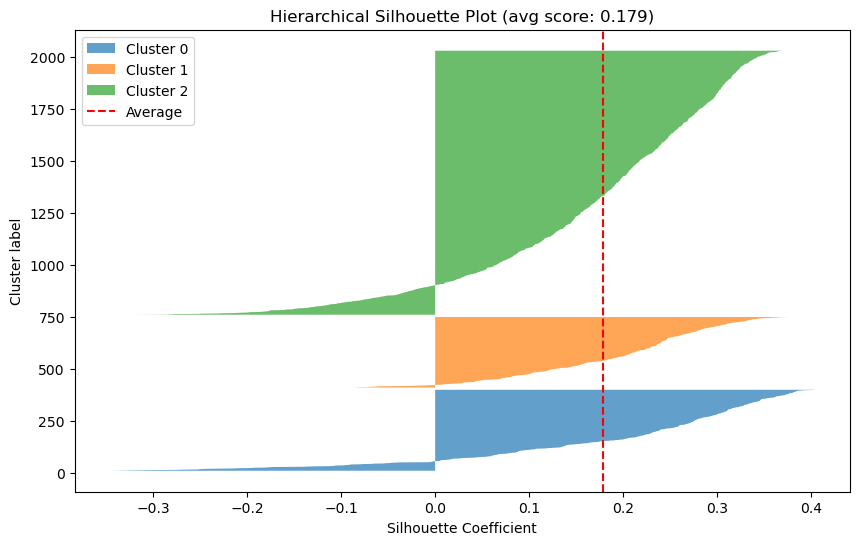

In [84]:
# Calculate silhouette score for Hierarchical clustering
silhouette_avg_hier = silhouette_score(X_scaled, clusters_hier - 1)
print(f"Hierarchical Silhouette Score: {silhouette_avg_hier:.3f}")

# Silhouette analysis plot
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(3):
    cluster_silhouette_vals = silhouette_samples(X_scaled, clusters_hier - 1)[clusters_hier - 1 == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster label')
ax.set_title(f'Hierarchical Silhouette Plot (avg score: {silhouette_avg_hier:.3f})')
ax.axvline(x=silhouette_avg_hier, color='red', linestyle='--', label='Average')
ax.legend()
plt.show()

## SOM

In [85]:
!pip install minisom

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 1.0050545766748293
SOM cluster sizes:
cluster_som
0    712
1    485
2    803
dtype: int64


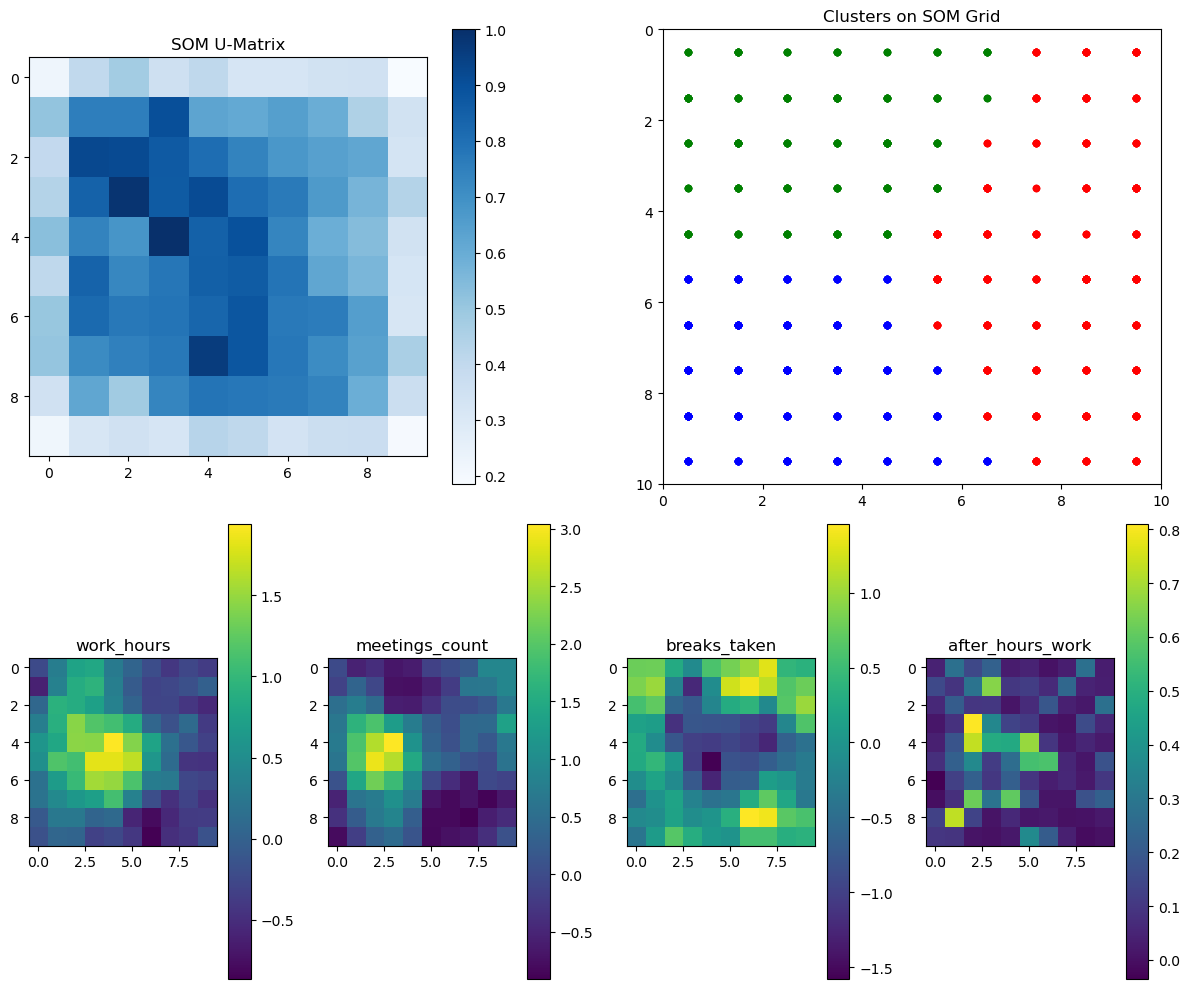

In [86]:
from minisom import MiniSom
import numpy as np

# Initialize SOM with a 10x10 grid
som_size = 10
som = MiniSom(som_size, som_size, X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)

# Train the SOM
som.train(X_scaled, 1000, verbose=True)

# Get the winning neurons for each data point
winner_coordinates = np.array([som.winner(x) for x in X_scaled])

# Create a mapping from SOM coordinates to cluster labels
from sklearn.cluster import KMeans
som_clusters = KMeans(n_clusters=3, random_state=42).fit_predict(winner_coordinates)

# Add SOM clusters to dataframe
df['cluster_som'] = som_clusters

print("SOM cluster sizes:")
print(df.groupby('cluster_som').size())

# Visualize SOM results
plt.figure(figsize=(12, 10))

# Plot 1: U-Matrix (distance between neurons)
plt.subplot(2, 2, 1)
plt.title('SOM U-Matrix')
u_matrix = som.distance_map()
plt.imshow(u_matrix, cmap='Blues')
plt.colorbar()

# Plot 2: Clusters on SOM grid
plt.subplot(2, 2, 2)
plt.title('Clusters on SOM Grid')
colors = ['blue', 'green', 'red']
for i, (x, y) in enumerate(winner_coordinates):
    plt.scatter(x + 0.5, y + 0.5, color=colors[som_clusters[i]], alpha=0.6, s=20)
plt.xlim(0, som_size)
plt.ylim(0, som_size)
plt.gca().invert_yaxis()

# Plot 3: Component planes (first 4 features)
feature_names = habit_features[:4]  # Show first 4 features
for i, feature in enumerate(feature_names):
    plt.subplot(2, 4, 5 + i)
    plt.title(f'{feature}')
    weights = som.get_weights()[:, :, i]
    plt.imshow(weights, cmap='viridis')
    plt.colorbar()

plt.tight_layout()
plt.show()

# DBScan

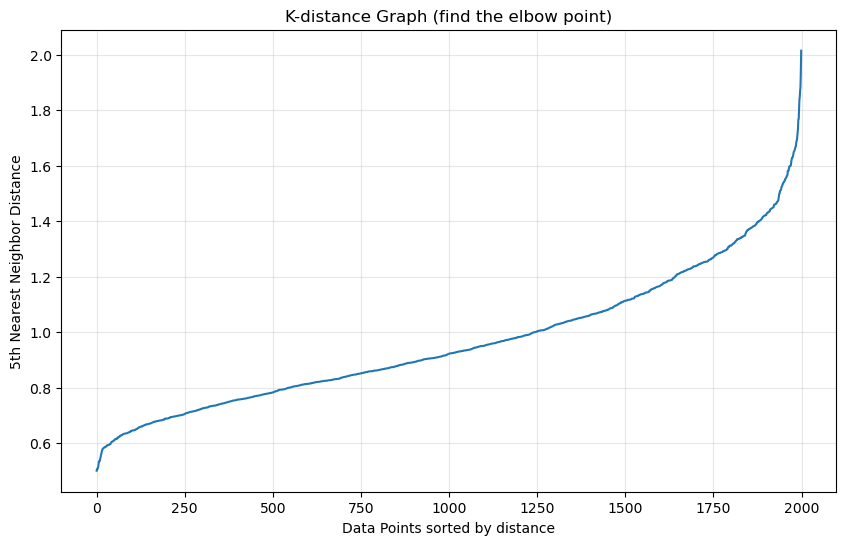

Distance percentiles:
  50th: 0.922
  60th: 0.982
  70th: 1.061
  75th: 1.113
  80th: 1.168
  90th: 1.312

Using 70th percentile eps value: 1.061

DBSCAN cluster counts (eps=1.061):
cluster_dbscan
-1     326
 0    1537
 1      58
 2      51
 3      23
 4       5
Name: count, dtype: int64
Noise points: 326
Number of clusters: 5


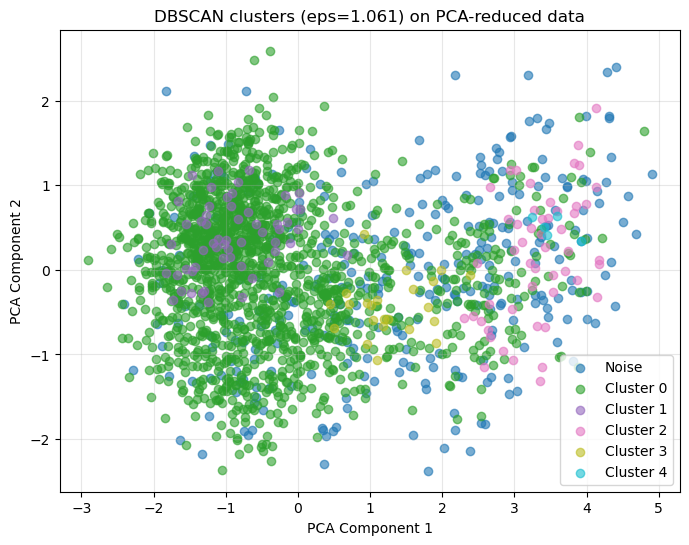

In [87]:
# Find optimal eps using k-distance graph
from sklearn.neighbors import NearestNeighbors

k = 5  # min_samples value
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph to find elbow
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('5th Nearest Neighbor Distance')
plt.xlabel('Data Points sorted by distance')
plt.title('K-distance Graph (find the elbow point)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Distance percentiles:")
print(f"  50th: {np.percentile(distances, 50):.3f}")
print(f"  60th: {np.percentile(distances, 60):.3f}")
print(f"  70th: {np.percentile(distances, 70):.3f}")
print(f"  75th: {np.percentile(distances, 75):.3f}")
print(f"  80th: {np.percentile(distances, 80):.3f}")
print(f"  90th: {np.percentile(distances, 90):.3f}")

# Try lower percentile for more clusters (adjust this value to find sweet spot)
percentile_to_use = 70  # More granular than 90th
suggested_eps = np.percentile(distances, percentile_to_use)
print(f"\nUsing {percentile_to_use}th percentile eps value: {suggested_eps:.3f}")

# Now fit DBSCAN with better eps
X_scaled_df = pd.DataFrame(X_scaled, columns=habit_features)
dbscan_labels = DBSCAN(eps=suggested_eps, min_samples=5).fit_predict(X_scaled_df)

df['cluster_dbscan'] = dbscan_labels

print(f'\nDBSCAN cluster counts (eps={suggested_eps:.3f}):')
print(df['cluster_dbscan'].value_counts().sort_index())
print(f"Noise points: {(dbscan_labels == -1).sum()}")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")

# Visualize DBSCAN clustering with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
colors = plt.cm.get_cmap('tab10', max(1, len(unique_labels)))
for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label_name, alpha=0.6,
                color=colors(idx))

plt.title(f'DBSCAN clusters (eps={suggested_eps:.3f}) on PCA-reduced data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [88]:
import pickle

# Assuming 'loaded_data' is the dictionary you loaded from processed_data.pkl
# and 'kmeans_3' is your final fitted KMeans model with 3 clusters

final_app_data = {
    'scaler': loaded_data['scaler'],  # This grabs your RobustScaler from EDA!
    'kmeans': kmeans_3,                 # Your final model
    'features': loaded_data['feature_names']
}

with open('final_app_model.pkl', 'wb') as f:
    pickle.dump(final_app_data, f)

print("App model saved successfully!")

App model saved successfully!
